In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

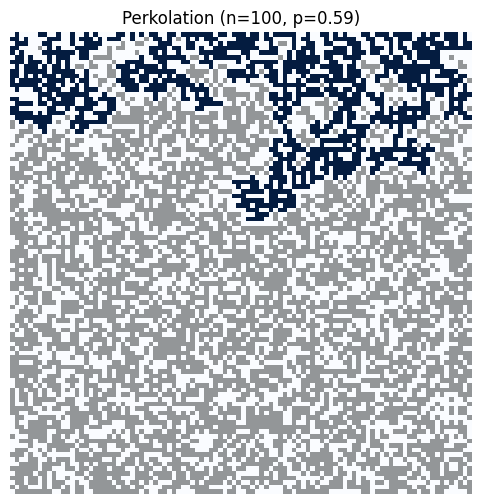

Keine Perkolation (kein durchgehender Pfad).


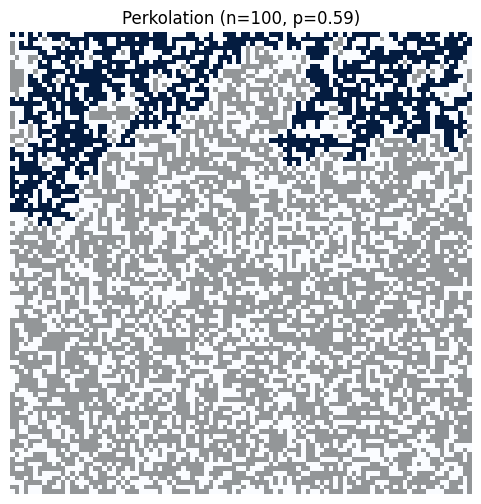

Keine Perkolation (kein durchgehender Pfad).


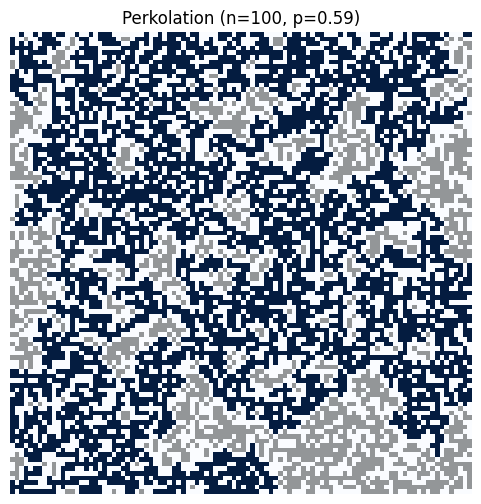

Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)


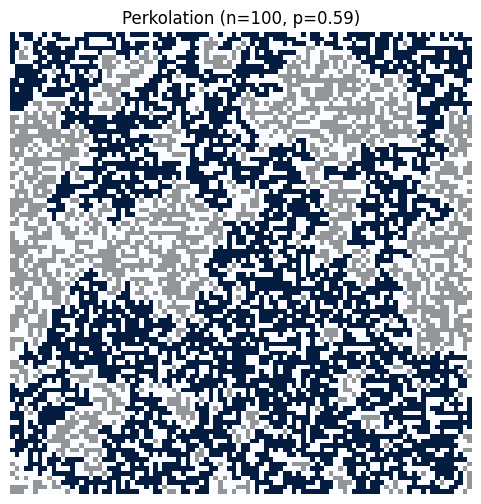

Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)


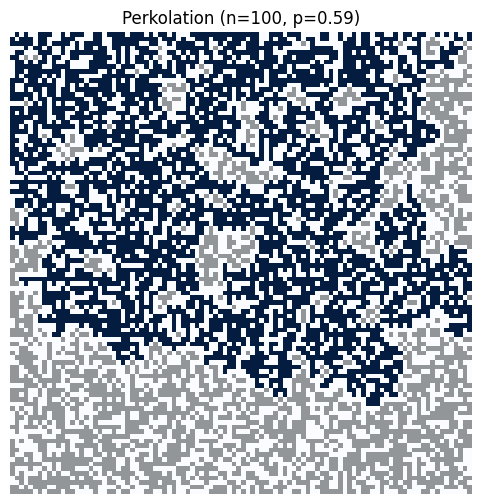

Keine Perkolation (kein durchgehender Pfad).


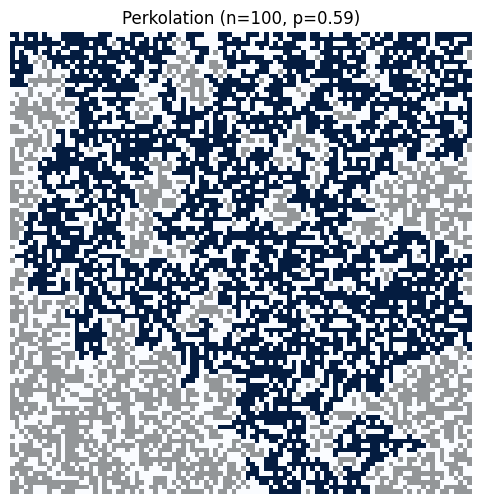

Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)


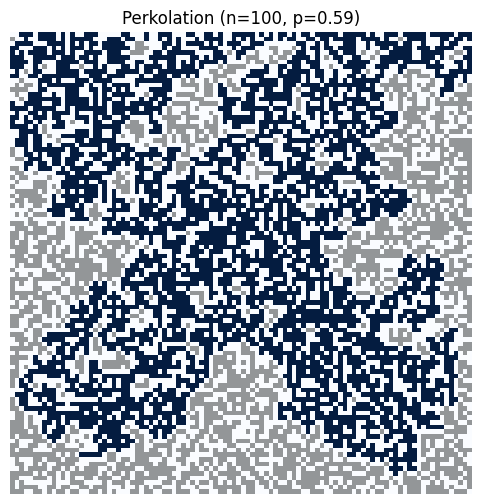

Keine Perkolation (kein durchgehender Pfad).


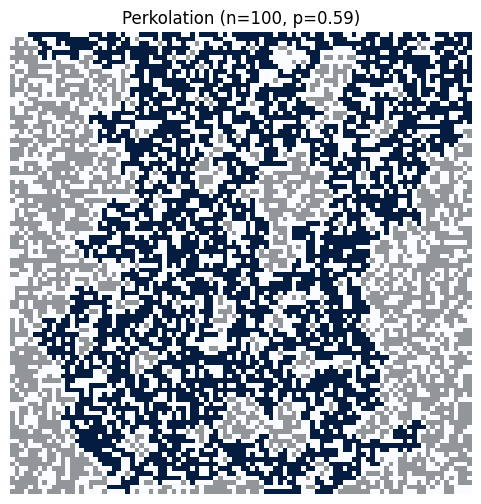

Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)


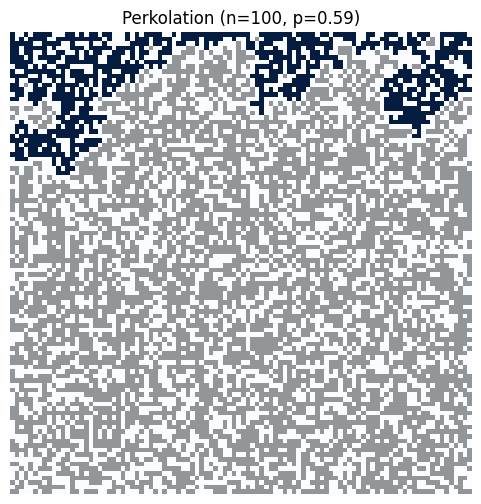

Keine Perkolation (kein durchgehender Pfad).


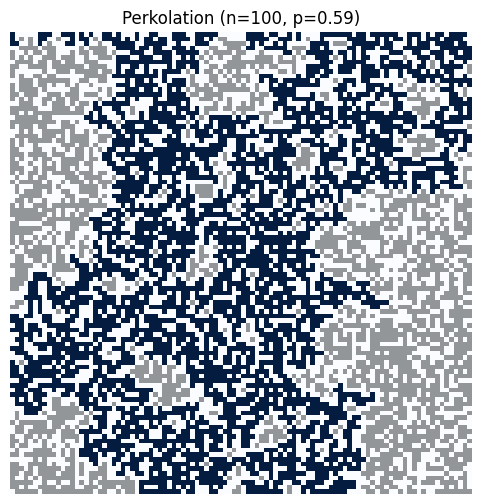

Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)


In [2]:


for i in range(10):
    def simulation_perkolation(n=50, p=0.55):
        """
        n = Größe des Gitters (n x n)
        p = Wahrscheinlichkeit, dass eine Pore offen ist
        """
        # 1. Erzeuge ein zufälliges Gitter: True = offen, False = blockiert
        grid = np.random.rand(n, n) < p

        # 2. Flood-fill von oben starten (wie Wasser, das oben in den Filter läuft)
        wet = np.zeros_like(grid, dtype=bool)
        queue = deque()

        # Start: alle offenen Zellen der ersten Zeile
        for j in range(n):
            if grid[0, j]:
                wet[0, j] = True
                queue.append((0, j))

        # BFS / Flood-Fill
        while queue:
            x, y = queue.popleft()

            # Nachbarn (oben, unten, links, rechts)
            for dx, dy in [(1,0), (-1,0), (0,1), (0,-1)]:
                nx, ny = x + dx, y + dy

                # Check boundaries
                if 0 <= nx < n and 0 <= ny < n:
                    if grid[nx, ny] and not wet[nx, ny]:
                        wet[nx, ny] = True
                        queue.append((nx, ny))

        return grid, wet


    # --- Simulation starten ---
    n = 100   # Filtergröße
    p = 0.59  # Offenheits-Wahrscheinlichkeit (Perkolationsschwelle ≈ 0.59 beim 2D-Gitter)

    grid, wet = simulation_perkolation(n, p)



    # --- Visualisieren ---
    plt.figure(figsize=(6,6))
    plt.imshow(grid, cmap="Greys", interpolation="nearest")
    plt.imshow(wet, cmap="Blues", alpha=0.6, interpolation="nearest")
    plt.title(f"Perkolation (n={n}, p={p})")
    plt.axis("off")
    plt.show()

    # --- Prüfen, ob Wasser unten angekommen ist ---
    if wet[-1].any():
        print("Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)")
    else:
        print("Keine Perkolation (kein durchgehender Pfad).")


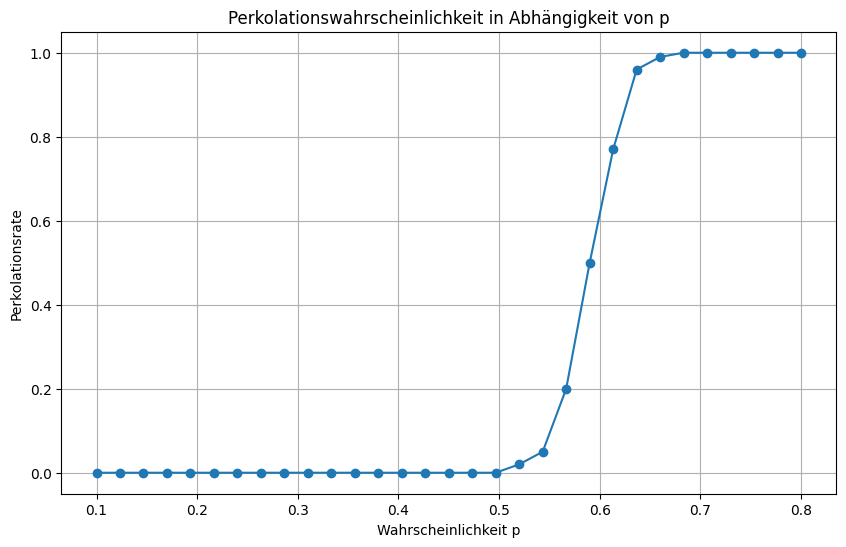

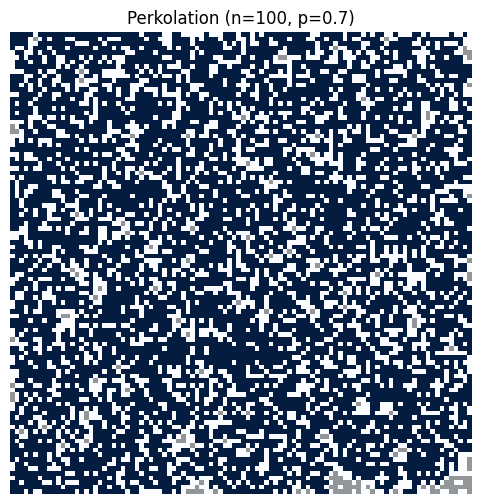

Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)


In [3]:


def simulation_perkolation(n=50, p=0.55):
    """
    n = Größe des Gitters (n x n)
    p = Wahrscheinlichkeit, dass eine Pore offen ist
    """
    # 1. Erzeuge ein zufälliges Gitter: True = offen, False = blockiert
    grid = np.random.rand(n, n) < p

    # 2. Flood-fill von oben starten (wie Wasser, das oben in den Filter läuft)
    wet = np.zeros_like(grid, dtype=bool)
    queue = deque()

    # Start: alle offenen Zellen der ersten Zeile
    for j in range(n):
        if grid[0, j]:
            wet[0, j] = True
            queue.append((0, j))

    # BFS / Flood-Fill
    while queue:
        x, y = queue.popleft()

        # Nachbarn (oben, unten, links, rechts)
        for dx, dy in [(1,0), (-1,0), (0,1), (0,-1)]:
            nx, ny = x + dx, y + dy

            # Check boundaries
            if 0 <= nx < n and 0 <= ny < n:
                if grid[nx, ny] and not wet[nx, ny]:
                    wet[nx, ny] = True
                    queue.append((nx, ny))

    return grid, wet

# --- Neue Simulation: Perkolationswahrscheinlichkeit über p ---
n = 50  # Kleinere Größe für schnellere Simulation
p_values = np.linspace(0.1, 0.8, 31)  # p von 0.4 bis 0.7 in Schritten von 0.01
num_simulations = 100  # Anzahl Simulationen pro p
percolation_rates = []

for p in p_values:
    percolations = 0
    for _ in range(num_simulations):
        grid, wet = simulation_perkolation(n, p)
        if wet[-1].any():
            percolations += 1
    rate = percolations / num_simulations
    percolation_rates.append(rate)

# Schaubild erstellen
plt.figure(figsize=(10, 6))
plt.plot(p_values, percolation_rates, marker='o', linestyle='-')
plt.title('Perkolationswahrscheinlichkeit in Abhängigkeit von p')
plt.xlabel('Wahrscheinlichkeit p')
plt.ylabel('Perkolationsrate')
plt.grid(True)
plt.show()

# --- Einzelne Simulation für Visualisierung ---
n = 100
p = 0.70
grid, wet = simulation_perkolation(n, p)

plt.figure(figsize=(6,6))
plt.imshow(grid, cmap="Greys", interpolation="nearest")
plt.imshow(wet, cmap="Blues", alpha=0.6, interpolation="nearest")
plt.title(f"Perkolation (n={n}, p={p})")
plt.axis("off")
plt.show()

if wet[-1].any():
    print("Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)")
else:
    print("Keine Perkolation (kein durchgehender Pfad).")

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Widgets für Parameter
n_slider = widgets.IntSlider(value=50, min=10, max=1000, step=10, description='Gittergröße n:')
p_slider = widgets.FloatSlider(value=0.59, min=0.0, max=1.0, step=0.01, description='Wahrscheinlichkeit p:')
num_sim_slider = widgets.IntSlider(value=100, min=10, max=1000, step=50, description='Simulationen pro p:')
run_button = widgets.Button(description='Simulation starten')

output = widgets.Output()

def run_simulations(b):
    with output:
        clear_output(wait=True)
        n = n_slider.value
        p = p_slider.value
        num_simulations = num_sim_slider.value
        
        print(f"Starte Simulation mit n={n}, p={p}, {num_simulations} Läufen...")
        
        # Einzelne Simulation für Visualisierung
        grid, wet = simulation_perkolation(n, p)
        plt.figure(figsize=(6,6))
        plt.imshow(grid, cmap="Greys", interpolation="nearest")
        plt.imshow(wet, cmap="Blues", alpha=0.6, interpolation="nearest")
        plt.title(f"Perkolation (n={n}, p={p})")
        plt.axis("off")
        plt.show()
        
        if wet[-1].any():
            print("Wasser perkoliert bis zum Boden! (Durchgehender Pfad vorhanden)")
        else:
            print("Keine Perkolation (kein durchgehender Pfad).")
        
        # Mehrere Simulationen für Wahrscheinlichkeit
        p_values = np.linspace(0.1, 0.9, 31)
        percolation_rates = []
        for p_val in p_values:
            percolations = 0
            for _ in range(num_simulations):
                grid, wet = simulation_perkolation(n, p_val)
                if wet[-1].any():
                    percolations += 1
            rate = percolations / num_simulations
            percolation_rates.append(rate)
        
        plt.figure(figsize=(10, 6))
        plt.plot(p_values, percolation_rates, marker='o', linestyle='-')
        plt.title('Perkolationswahrscheinlichkeit in Abhängigkeit von p')
        plt.xlabel('Wahrscheinlichkeit p')
        plt.ylabel('Perkolationsrate')
        plt.grid(True)
        plt.show()

run_button.on_click(run_simulations)

# Anzeige der Widgets
display(n_slider, p_slider, num_sim_slider, run_button, output)

IntSlider(value=50, description='Gittergröße n:', max=1000, min=10, step=10)

FloatSlider(value=0.59, description='Wahrscheinlichkeit p:', max=1.0, step=0.01)

IntSlider(value=100, description='Simulationen pro p:', max=1000, min=10, step=50)

Button(description='Simulation starten', style=ButtonStyle())

Output()

https://youtu.be/p5FIVTkGiXo?si=3LG8gysfYrcf1Kpx
ChatGPT
GitHub Copilot
https://de.wikipedia.org/wiki/Perkolation_(Technik)
https://myweb.rz.uni-augsburg.de/~oldenbre/experimente/Perkolation.pdf
https://www2.mathematik.tu-darmstadt.de/~stochastik/LNM/LNM_Perkolation.pdf
https://github.com/mrbrianevans/percolation